In [1]:
import os
import pickle as pkl
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join("..", "src")))
import utils

In [2]:
try:
    x0 = np.load("../scripts/variables/x0_00.npy")
    inputs = np.load("../scripts/variables/inputs_00.npy")
    states = ["BG (mmol/L)", "I (mU/L)", "Q (mu/L)", "P1 (mmol)", "P2 (mmol)"]
    input_labels = ["uex (mU/min)", "D (mmol/min)", "PN (mmol/min)", "SI"]
    print("Loaded variables from previous runs")
except Exception:
    print("Run 00_Parameter_Distributions.py script")

Loaded variables from previous runs


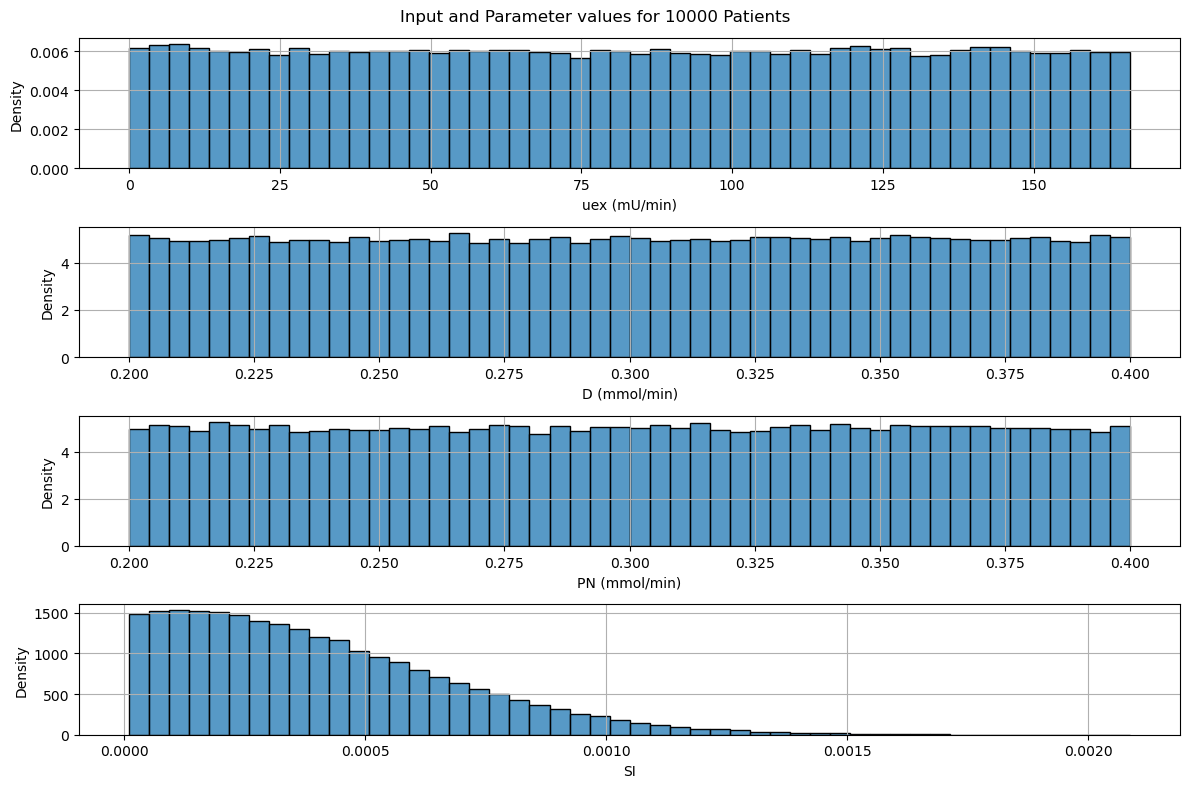

In [3]:
fig, ax = plt.subplots(inputs.shape[0], 1, figsize=(12, 8))
for i in range(inputs.shape[0]):
    sns.histplot(data=inputs[i, :], bins=50, stat="density", ax=ax[i])
    ax[i].set_xlabel(input_labels[i])
    ax[i].grid()
fig.suptitle("Input and Parameter values for 10000 Patients")
fig.tight_layout()

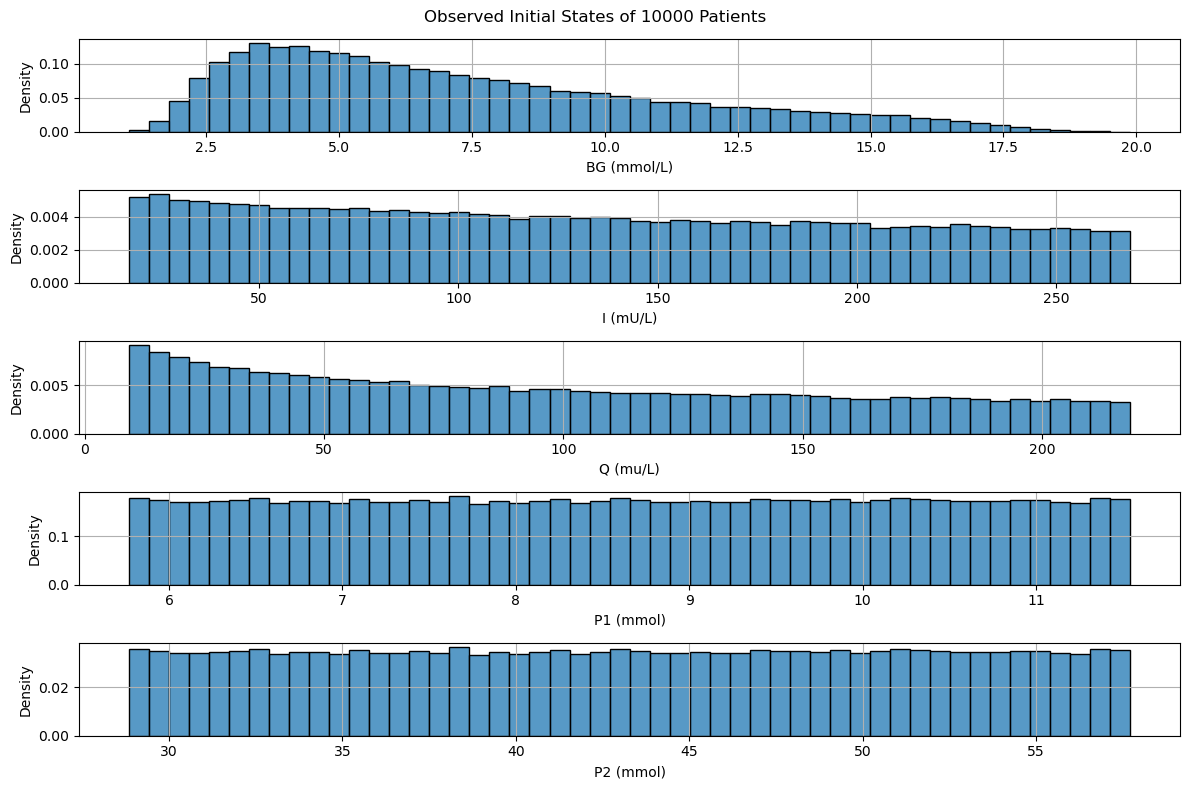

In [4]:
fig, ax = plt.subplots(x0.shape[0], 1, figsize=(12, 8))
for i in range(x0.shape[0]):
    sns.histplot(data=x0[i, :], bins=50, stat="density", ax=ax[i])
    ax[i].set_xlabel(states[i])
    ax[i].grid()
fig.suptitle("Observed Initial States of 10000 Patients")
fig.tight_layout()

In [5]:
print("Mean initial states: ", np.mean(x0, axis=1))
print("Initial Covariance: \n", np.cov(x0, rowvar=True, bias=False))

Mean initial states:  [  7.36622823 132.91994064  98.06971075   8.66109432  43.30547161]
Initial Covariance: 
 [[ 1.53534861e+01 -1.05771317e+02 -8.65444216e+01  4.79129671e-01
   2.39564835e+00]
 [-1.05771317e+02  5.28079472e+03  4.44633704e+03 -2.01339883e-01
  -1.00669942e+00]
 [-8.65444216e+01  4.44633704e+03  3.75481584e+03 -1.62147923e-01
  -8.10739613e-01]
 [ 4.79129671e-01 -2.01339883e-01 -1.62147923e-01  2.78163989e+00
   1.39081995e+01]
 [ 2.39564835e+00 -1.00669942e+00 -8.10739613e-01  1.39081995e+01
   6.95409973e+01]]


In [6]:
try:
    patient_data = pkl.load(open("../scripts/variables/patient_data_00.pkl", "rb"))
    print("Loaded variable from previous run")
except Exception:
    print("Run 00_Patient_Cohort.py script")

Loaded variable from previous run


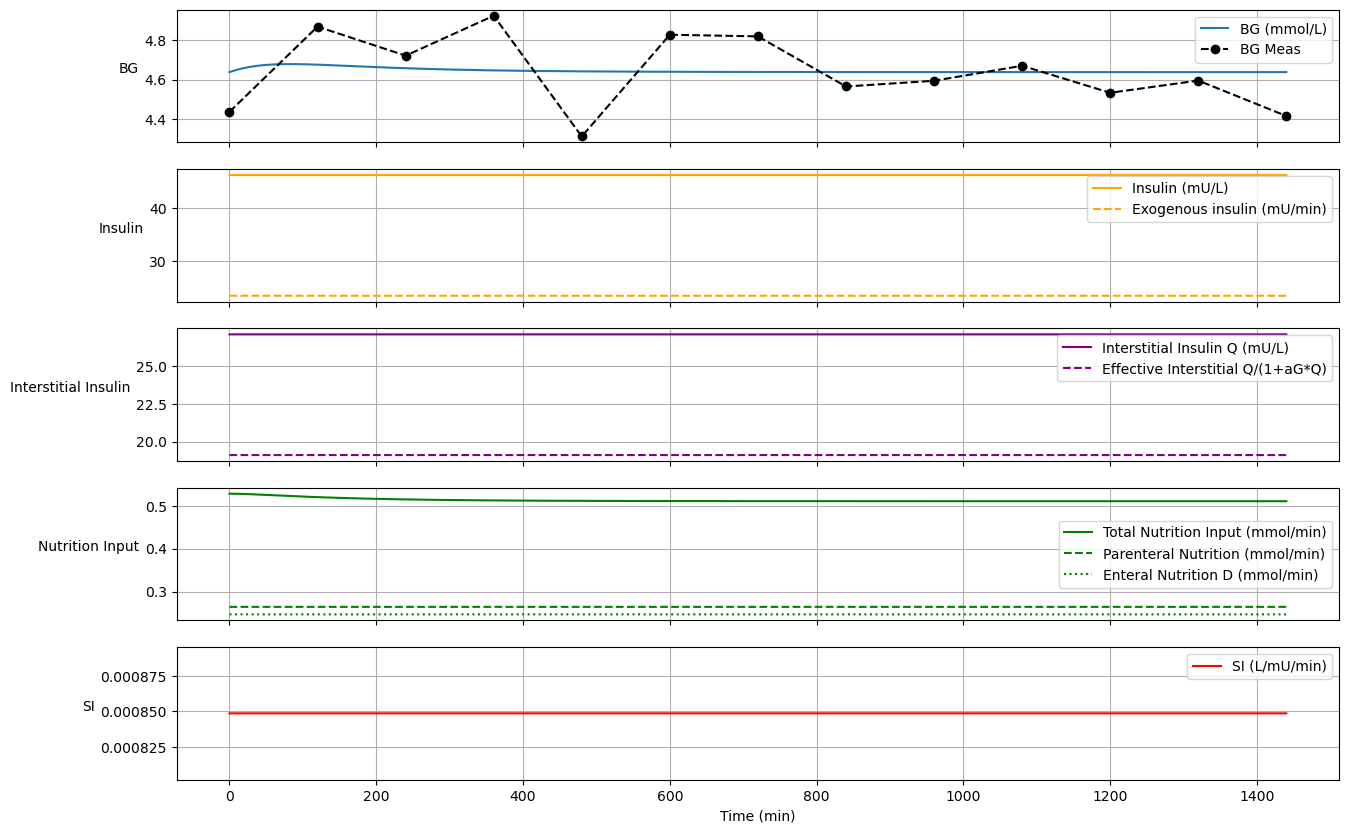

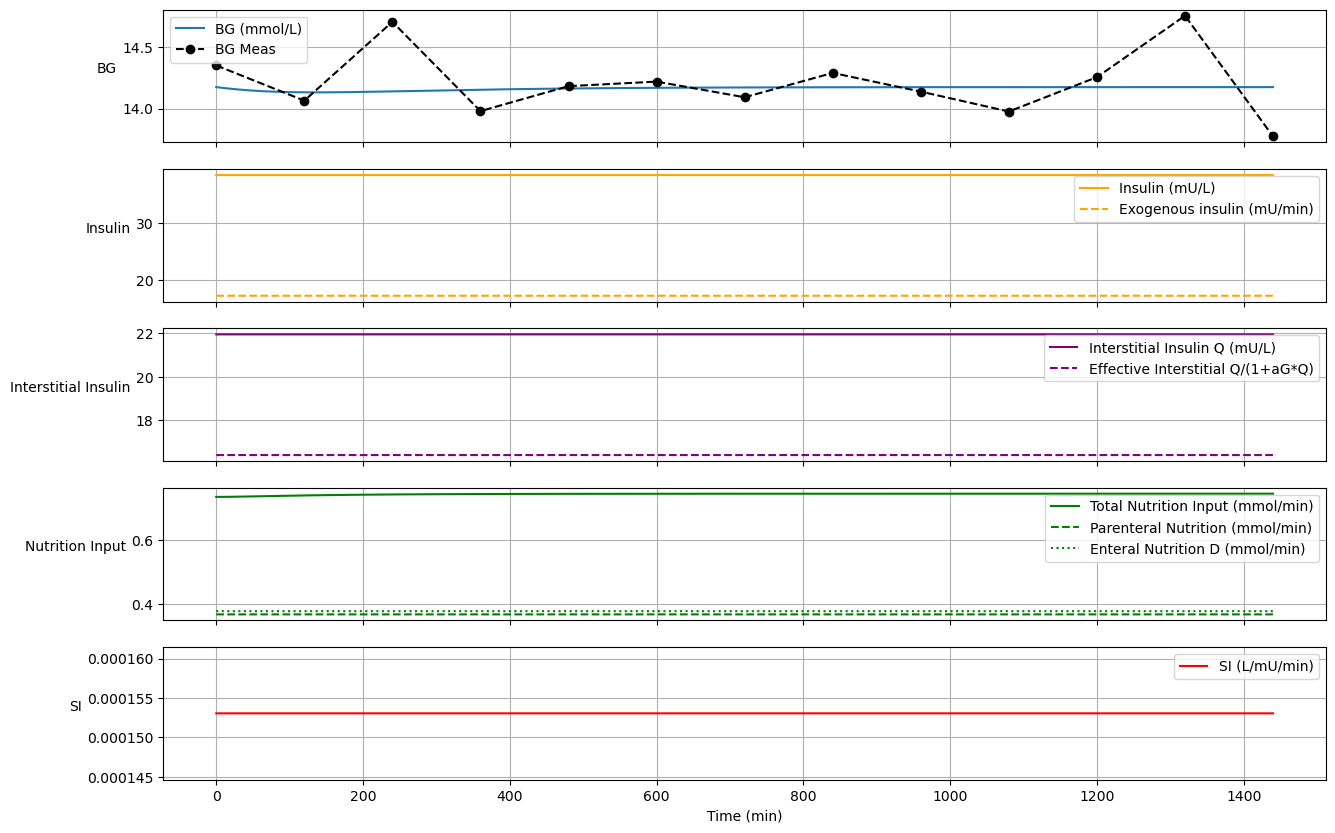

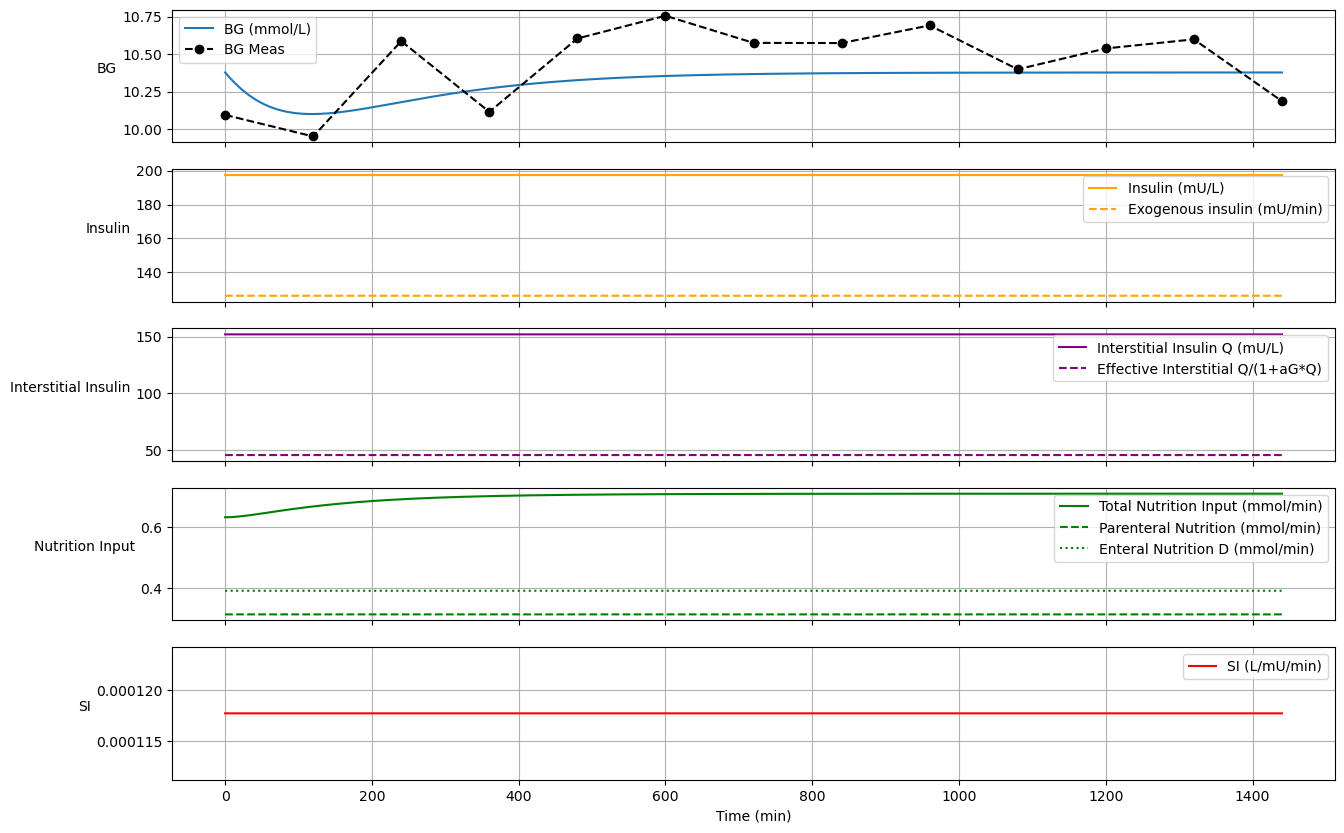

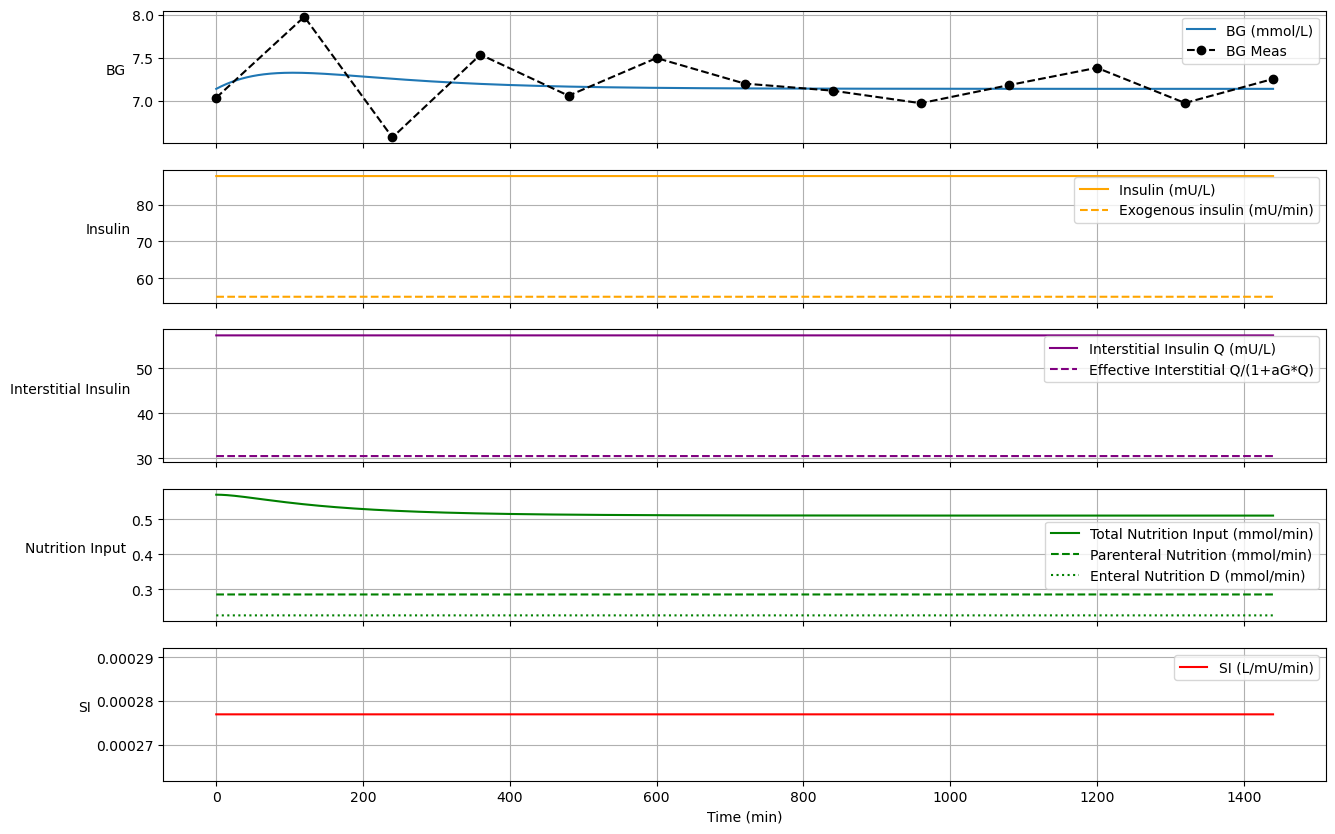

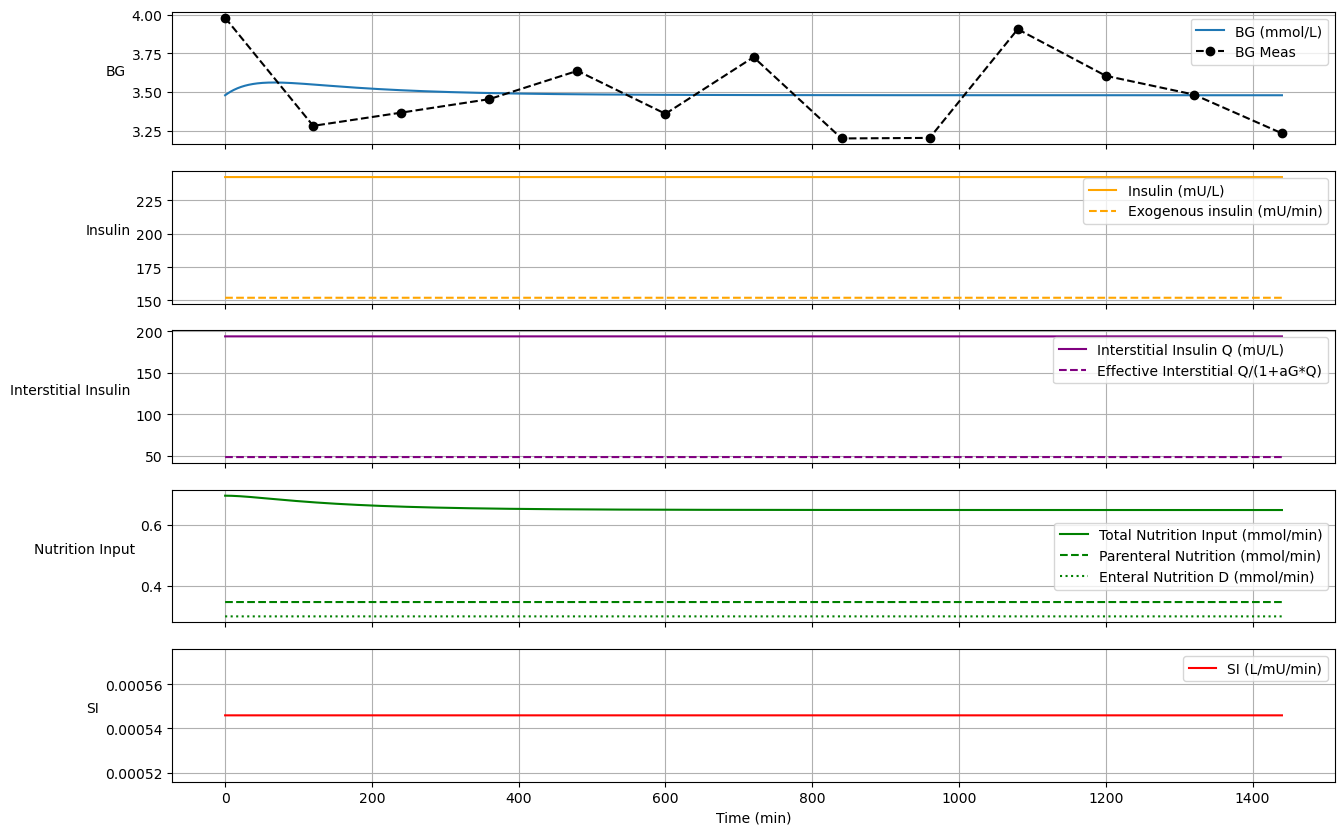

In [7]:
num_patients = len(patient_data)

for i in range(num_patients):
    G = patient_data[i]["BG"]
    G_meas = patient_data[i]["BG_meas"]
    Q = patient_data[i]["Q"]
    I = patient_data[i]["I"]  # noqa: E741
    P1 = patient_data[i]["P1"]
    P2 = patient_data[i]["P2"]
    P = patient_data[i]["P"]
    t = patient_data[i]["t"]
    t_meas = patient_data[i]["t_meas"]
    uex = patient_data[i]["uex"]
    D = patient_data[i]["D"]
    PN = patient_data[i]["PN"]
    SI = patient_data[i]["SI"]
    utils.plot_model(t, t_meas, G, G_meas, Q, I, P1, P2, P, uex, PN, D, SI)
